<div class="alert alert-block alert-success">


# **03 — feature engineering pipeline**

## **Goal of this notebook**
The raw columns in the database (goals, minutes_played, date_of_birth, net_transfer_record) are not directly comparable or analytically useful on their own. This notebook derives meaningful metrics from the raw data so that every subsequent notebook has better inputs to work with. This is not analysis — it is preparation for analysis.

### **metrics to make**
**Player-level metrics** (aggregated from appearances)
- age — calculated from date_of_birth to a reference date (e.g. latest game date in dataset)
- contract_years_remaining — from contract_expiration_date to reference date
- goals_per_90 — goals / (minutes_played / 90), for players with sufficient appearances
- assists_per_90 — same approach
- goal_contributions_per_90 — (goals + assists) / (minutes_played / 90)
- minutes_played_ratio — minutes_played / (appearances × 90), a proxy for how often a player plays the full match vs gets substituted
- cards_per_90 — (yellow_cards + red_cards×2) / (minutes_played / 90)

**Club-level metrics** (aggregated from games)
- win_rate — wins / total_games
- goals_scored_per_game — total goals scored / total games
- goals_conceded_per_game — total goals conceded / total games
- goal_difference_per_game
- avg_attendance — average attendance across home games
- national_team_players_ratio — national team players / squad size
- foreigners_ratio — foreigners / squad size
- home_win_rate — home_wins / home_games
- away_win_rate — away_wins / away_games
- clean_sheet_rate — rate of the cleansheets for each club 
- points_per_game — average number of points club received across games 

**Game-level metrics** (only row-level metrics not aggregated)
- total_goals — home_club_goals + away_club_goals
- goal_difference — absolute difference between home and away goals
- is_draw, home_win, away_win — boolean outcome flags

##### **the changes are going to take place directly on the database not the raw data**

In [1]:
# importing the necessaries
import sys
import os
# Adding the root to the path to use utils folder
sys.path.append(os.path.abspath(os.path.join('..')))

from utils.db_utils import run_query , execute_ddl
from utils.custom_plots import distribution_plot, outlier_plot
from utils.schema_diagram import schema_diagram


import plotly.io as pio
pio.renderers.default = "png"  # drop these 2 lines if you want interactive charts locally

<div class="alert alert-block alert-success">

# First lets see the connections 
## here we can have a better understanding of cross-table metrics

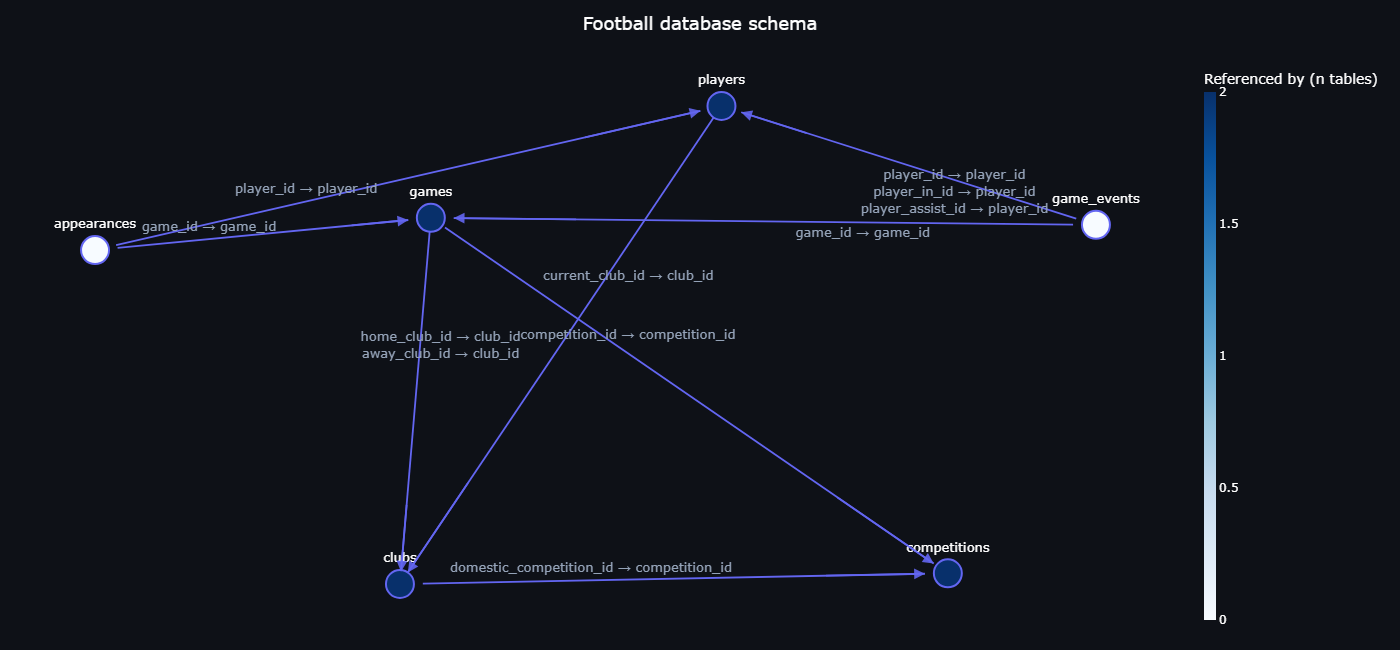

In [2]:
database_diagram=schema_diagram(run_query_fn=run_query,
                                layout='spring',
                                edge_labels='always',
                                title='Football database schema',
                                edge_label_font_size=13,
                                seed=51
                                )

database_diagram

<div class="alert alert-block alert-success">

# Player-level metrics:


In [3]:
# storing all the queries in a list and executing them at the end
all_metrics_query = []

# these first two queries are row-level metrics 
# we calculate the age based on the latest data which is 2025(not 2026) 
row_level_players_metric_query = r'''
ALTER TABLE players
ADD COLUMN age INT,
ADD COLUMN contract_years_remaining NUMERIC(4, 1);

UPDATE players
SET
    age = EXTRACT(YEAR FROM AGE(
              CAST('2025-01-01' AS DATE), date_of_birth
          ))::INT,
    contract_years_remaining = ROUND(
        EXTRACT(EPOCH FROM AGE(contract_expiration_date, CAST('2025-01-01' AS DATE)))
        / (365.25 * 24 * 3600)
    , 1);
'''


# we write a query for metrics that need aggregation  
# GENERATED ALWAYS AS doesnt work for metrics that need computation on more then 1 row so instead we define columns and populate them with computed value
# we need to define a threshold for ratio denominator so it doesnt explode the ratio with low values 

aggregated_players_metric_query = r'''
ALTER TABLE players
ADD COLUMN goals_per_90            NUMERIC(5, 2),
ADD COLUMN assists_per_90          NUMERIC(5, 2),
ADD COLUMN goal_contributions_per_90 NUMERIC(5, 2),
ADD COLUMN minutes_played_ratio    NUMERIC(4, 3),
ADD COLUMN cards_per_90            NUMERIC(5, 2),
ADD COLUMN total_appearances       INT,
ADD COLUMN total_minutes_played    INT;


UPDATE players p
SET
    total_appearances        = agg.appearances,
    total_minutes_played     = agg.total_minutes,
    goals_per_90             = CASE 
                                 WHEN agg.total_minutes >= 200 
                                 THEN ROUND(agg.total_goals / (agg.total_minutes / 90.0), 2) 
                               END,
    assists_per_90           = CASE 
                                 WHEN agg.total_minutes >= 200 
                                 THEN ROUND(agg.total_assists / (agg.total_minutes / 90.0), 2) 
                               END,
    goal_contributions_per_90 = CASE 
                                 WHEN agg.total_minutes >= 200 
                                 THEN ROUND((agg.total_goals + agg.total_assists) / (agg.total_minutes / 90.0), 2) 
                               END,
    minutes_played_ratio     = CASE 
                                 WHEN agg.appearances > 5
                                 THEN ROUND(agg.total_minutes / (agg.appearances * 90.0), 3) 
                               END,
    cards_per_90             = CASE 
                                 WHEN agg.total_minutes >= 200 
                                 THEN ROUND((agg.yellow_cards + agg.red_cards * 2) / (agg.total_minutes / 90.0), 2) 
                               END
FROM (
    SELECT
        player_id,
        COUNT(*)             AS appearances,
        SUM(minutes_played)  AS total_minutes,
        SUM(goals)           AS total_goals,
        SUM(assists)         AS total_assists,
        SUM(yellow_cards)    AS yellow_cards,
        SUM(red_cards)       AS red_cards
    FROM appearances
    GROUP BY player_id
) agg
WHERE p.player_id = agg.player_id;
'''

all_metrics_query.extend([row_level_players_metric_query,
                         aggregated_players_metric_query])

<div class="alert alert-block alert-success">

## Player-level metrics summary:

- age — the player's current age in completed years as of the reference date
- contract_years_remaining — how many years (as a decimal) until the player's contract expires, negative means already expired
- goals_per_90 — how many goals the player scores on average per 90 minutes of play
- assists_per_90 — how many assists the player produces on average per 90 minutes of play
- goal_contributions_per_90 — combined goals and assists per 90 minutes, measuring total attacking output regardless of who finished
- minutes_played_ratio — what fraction of available minutes the player actually plays, where 1.0 means they play every minute of every game they appear in, values above 1.0 are unlikely but possible it means the players average play time is more than 90 minute because of extra times 
- cards_per_90 — disciplinary load per 90 minutes, treating a red card as twice the weight of a yellow
- total_appearances — total number of games the player appeared in across all recorded seasons
- total_minutes_played — total minutes across all appearances, the denominator behind every per-90 metric

<div class="alert alert-block alert-success">

# Game-level metrics:


In [4]:
row_level_game_metric_query = r'''
ALTER TABLE games
ADD COLUMN total_goals INT GENERATED ALWAYS AS (
    home_club_goals + away_club_goals
) STORED;

ALTER TABLE games
ADD COLUMN goal_difference INT GENERATED ALWAYS AS (
    ABS(home_club_goals - away_club_goals)
) STORED;

ALTER TABLE games
ADD COLUMN is_draw BOOLEAN GENERATED ALWAYS AS (
    home_club_goals = away_club_goals
) STORED;

ALTER TABLE games
ADD COLUMN home_win BOOLEAN GENERATED ALWAYS AS (
    home_club_goals > away_club_goals
) STORED;

ALTER TABLE games
ADD COLUMN away_win BOOLEAN GENERATED ALWAYS AS (
    home_club_goals < away_club_goals
) STORED;
'''
# we dont need aggregated metrics for game-level metrics, these metrics make querying easier and cleaner

all_metrics_query.extend([row_level_game_metric_query])

<div class="alert alert-block alert-success">

## Game-level metrics summary:

- total_goals — combined goals from both teams in a single match, a measure of how open or entertaining the game was
- goal_difference — absolute gap between the two teams' scores, measuring how decisive the result was
- is_draw — whether the match ended level
- home_win — whether the home team won
- away_win — whether the away team won

<div class="alert alert-block alert-success">

# Club-level metrics:

In [5]:
# first lets define the aggregated metrics 
# we also define the same threshold for ratio metrics with the same logic implemented in the player-level metrics

aggregated_club_metric_query1 = r'''
ALTER TABLE clubs
ADD COLUMN win_rate               NUMERIC(4, 3),
ADD COLUMN goals_scored_per_game  NUMERIC(5, 2),
ADD COLUMN goals_conceded_per_game NUMERIC(5, 2),
ADD COLUMN goal_difference_per_game NUMERIC(5, 2),
ADD COLUMN avg_attendance         NUMERIC(10, 1),
ADD COLUMN total_games            INT;

UPDATE clubs c
SET
    total_games              = agg.total_games,

    win_rate                 = CASE
                                WHEN agg.total_games > 8
                                THEN ROUND(agg.wins::NUMERIC / NULLIF(agg.total_games, 0), 3)
                                END,

    goals_scored_per_game    = CASE
                                WHEN agg.total_games > 8
                                THEN ROUND(agg.goals_scored::NUMERIC / NULLIF(agg.total_games, 0), 2)
                                END,

    goals_conceded_per_game  = CASE
                                WHEN agg.total_games > 8
                                THEN ROUND(agg.goals_conceded::NUMERIC / NULLIF(agg.total_games, 0), 2)
                                END,

    goal_difference_per_game = CASE
                                WHEN agg.total_games > 8
                                THEN ROUND((agg.goals_scored - agg.goals_conceded)::NUMERIC / NULLIF(agg.total_games, 0), 2)
                                END,
                                
    avg_attendance           = ROUND(agg.avg_attendance, 1)
FROM (
    SELECT
        club_id,
        COUNT(*)                  AS total_games,
        SUM(goals_scored)         AS goals_scored,
        SUM(goals_conceded)       AS goals_conceded,
        SUM(wins)                 AS wins,
        AVG(attendance)           AS avg_attendance
    FROM (
        -- club as home team
        SELECT
            home_club_id        AS club_id,
            home_club_goals     AS goals_scored,
            away_club_goals     AS goals_conceded,
            CASE WHEN home_club_goals > away_club_goals THEN 1 ELSE 0 END AS wins,
            attendance
        FROM games
        WHERE home_club_goals IS NOT NULL

        UNION ALL      -- to catch both home-away teams stats

        -- club as away team
        SELECT
            away_club_id        AS club_id,
            away_club_goals     AS goals_scored,
            home_club_goals     AS goals_conceded,
            CASE WHEN away_club_goals > home_club_goals THEN 1 ELSE 0 END AS wins,
            NULL                AS attendance  -- attendance belongs to home club only
        FROM games
        WHERE away_club_goals IS NOT NULL
    ) both_sides
    GROUP BY club_id
) agg
WHERE c.club_id = agg.club_id;
'''

# another aggregated query with the same structure to compute win rates per side 
# and compute two new metrics clean_sheet_rate and points_per_game which will become useful for richer analysis 

aggregated_club_metric_query2 = r'''
ALTER TABLE clubs
add column home_win_rate numeric(4, 3),
add column away_win_rate numeric(4, 3),
add column clean_sheet_rate numeric(4, 3),
add column points_per_game numeric(4, 2);

UPDATE clubs c
SET
    home_win_rate    = CASE
                        WHEN agg.home_games > 8
                        THEN ROUND(agg.home_wins::NUMERIC  / NULLIF(agg.home_games, 0),  3)
                        END,

    away_win_rate    = CASE
                        WHEN agg.away_games > 8
                        THEN ROUND(agg.away_wins::NUMERIC  / NULLIF(agg.away_games, 0),  3)
                        END,

    clean_sheet_rate = CASE
                        WHEN agg.total_games > 8
                        THEN ROUND(agg.total_clean_sheets::NUMERIC / NULLIF(agg.total_games, 0), 3)
                        END,

    points_per_game  = CASE
                        WHEN agg.total_games > 8
                        THEN ROUND((agg.total_wins * 3 + agg.total_draws * 1)::NUMERIC / NULLIF(agg.total_games, 0), 2)
                        END
                        
FROM (
    SELECT
    club_id,
    SUM(CASE WHEN side = 'home' THEN games     ELSE 0 END) AS home_games,
    SUM(CASE WHEN side = 'home' THEN wins      ELSE 0 END) AS home_wins,
    SUM(CASE WHEN side = 'away' THEN games     ELSE 0 END) AS away_games,
    SUM(CASE WHEN side = 'away' THEN wins      ELSE 0 END) AS away_wins,
    SUM(games)        AS total_games,
    SUM(wins)         AS total_wins,
    SUM(draws)        AS total_draws,
    SUM(clean_sheets) AS total_clean_sheets
FROM (
    SELECT
        home_club_id AS club_id,
        'home'       AS side,
        COUNT(*)     AS games,
        SUM(CASE WHEN home_club_goals > away_club_goals THEN 1 ELSE 0 END) AS wins,
        SUM(CASE WHEN home_club_goals = away_club_goals THEN 1 ELSE 0 END) AS draws,
        SUM(CASE WHEN away_club_goals = 0               THEN 1 ELSE 0 END) AS clean_sheets
    FROM games
    WHERE home_club_goals IS NOT NULL AND away_club_goals IS NOT NULL
    GROUP BY home_club_id

    UNION ALL

    SELECT
        away_club_id AS club_id,
        'away'       AS side,
        COUNT(*)     AS games,
        SUM(CASE WHEN away_club_goals > home_club_goals THEN 1 ELSE 0 END) AS wins,
        SUM(CASE WHEN away_club_goals = home_club_goals THEN 1 ELSE 0 END) AS draws,
        SUM(CASE WHEN home_club_goals = 0               THEN 1 ELSE 0 END) AS clean_sheets
    FROM games
    WHERE home_club_goals IS NOT NULL AND away_club_goals IS NOT NULL
    GROUP BY away_club_id
) both_sides
GROUP BY club_id
) agg
WHERE c.club_id = agg.club_id;
'''

# now we define row-level metrics 

row_level_club_metric_query = r'''
ALTER TABLE clubs
ADD COLUMN foreigners_ratio  NUMERIC(4, 3) GENERATED ALWAYS AS (
    ROUND(foreigners_number::NUMERIC / NULLIF(squad_size, 0), 3)
) STORED;

ALTER TABLE clubs
ADD COLUMN national_team_players_ratio NUMERIC(4, 3) GENERATED ALWAYS AS(
    ROUND(national_team_players::NUMERIC / NULLIF(squad_size, 0), 3)    
) STORED;
'''

all_metrics_query.extend([aggregated_club_metric_query1,
                         aggregated_club_metric_query2,
                         row_level_club_metric_query])

<div class="alert alert-block alert-success">

## club-level metrics summary:

- win_rate — proportion of games won out of all games played, between 0 and 1
- goals_scored_per_game — average goals scored per game across both home and away fixtures
- goals_conceded_per_game — average goals allowed per game, a measure of defensive performance
- goal_difference_per_game — average margin between goals scored and conceded, positive means the club typically outscores opponents
- avg_attendance — average number of spectators per home game, a proxy for club size and fan base
- total_games — total number of games recorded for the club, home and away combined
- home_win_rate — win rate of the club in home side , this metric and the next metric enables testing home-effect hypothesis
- away_win_rate — win rate of the club in away side
- clean_sheet_rate — rate of the games that the team did not concede any goals 
- points_per_game — average number of points club got in a game , between 0 and 3 (lose = 0 points, draw = 1 points, win = 3 points)
- foreigners_ratio — ratio of foreign players in the club 
- national_team_players_ratio — ratio of national team players in the club 

In [6]:
# executing all the ddl queries with execute_dll() function 

for query in all_metrics_query:
    execute_ddl(query=query) 


✓ Query executed successfully. Rows affected: 15360
✓ Query executed successfully. Rows affected: 12080
✓ Query executed successfully. Rows affected: -1
✓ Query executed successfully. Rows affected: 368
✓ Query executed successfully. Rows affected: 368
✓ Query executed successfully. Rows affected: -1


<div class="alert alert-block alert-success">

- **15360 - 12080 = 3280 players exist in the database but have no recorded appearances, so all their per-90 metrics are null.**
- **the -1 values are for GENERATED ALWAYS AS statements which doesnt affect rows**

<div class="alert alert-block alert-success">

# Now lets check the metrics with some basic plots
## Player-level metrics plot and overview:

In [7]:
players_df = run_query('select * from players')
players_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15360 entries, 0 to 15359
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   player_id                  15360 non-null  int64  
 1   current_club_id            15360 non-null  int64  
 2   player_code                15360 non-null  str    
 3   country_of_birth           13598 non-null  str    
 4   city_of_birth              14113 non-null  str    
 5   country_of_citizenship     14782 non-null  str    
 6   date_of_birth              15354 non-null  object 
 7   sub_position               15329 non-null  str    
 8   position                   15329 non-null  str    
 9   foot                       14384 non-null  str    
 10  height_in_cm               14363 non-null  float64
 11  contract_expiration_date   12928 non-null  object 
 12  age                        15354 non-null  float64
 13  contract_years_remaining   12928 non-null  float64
 14  g

<div class="alert alert-block alert-success">

- **number of nulls are okay and they have multiple reasons like null values in the appearance table and threshold we defined to have meaningful ratio** 

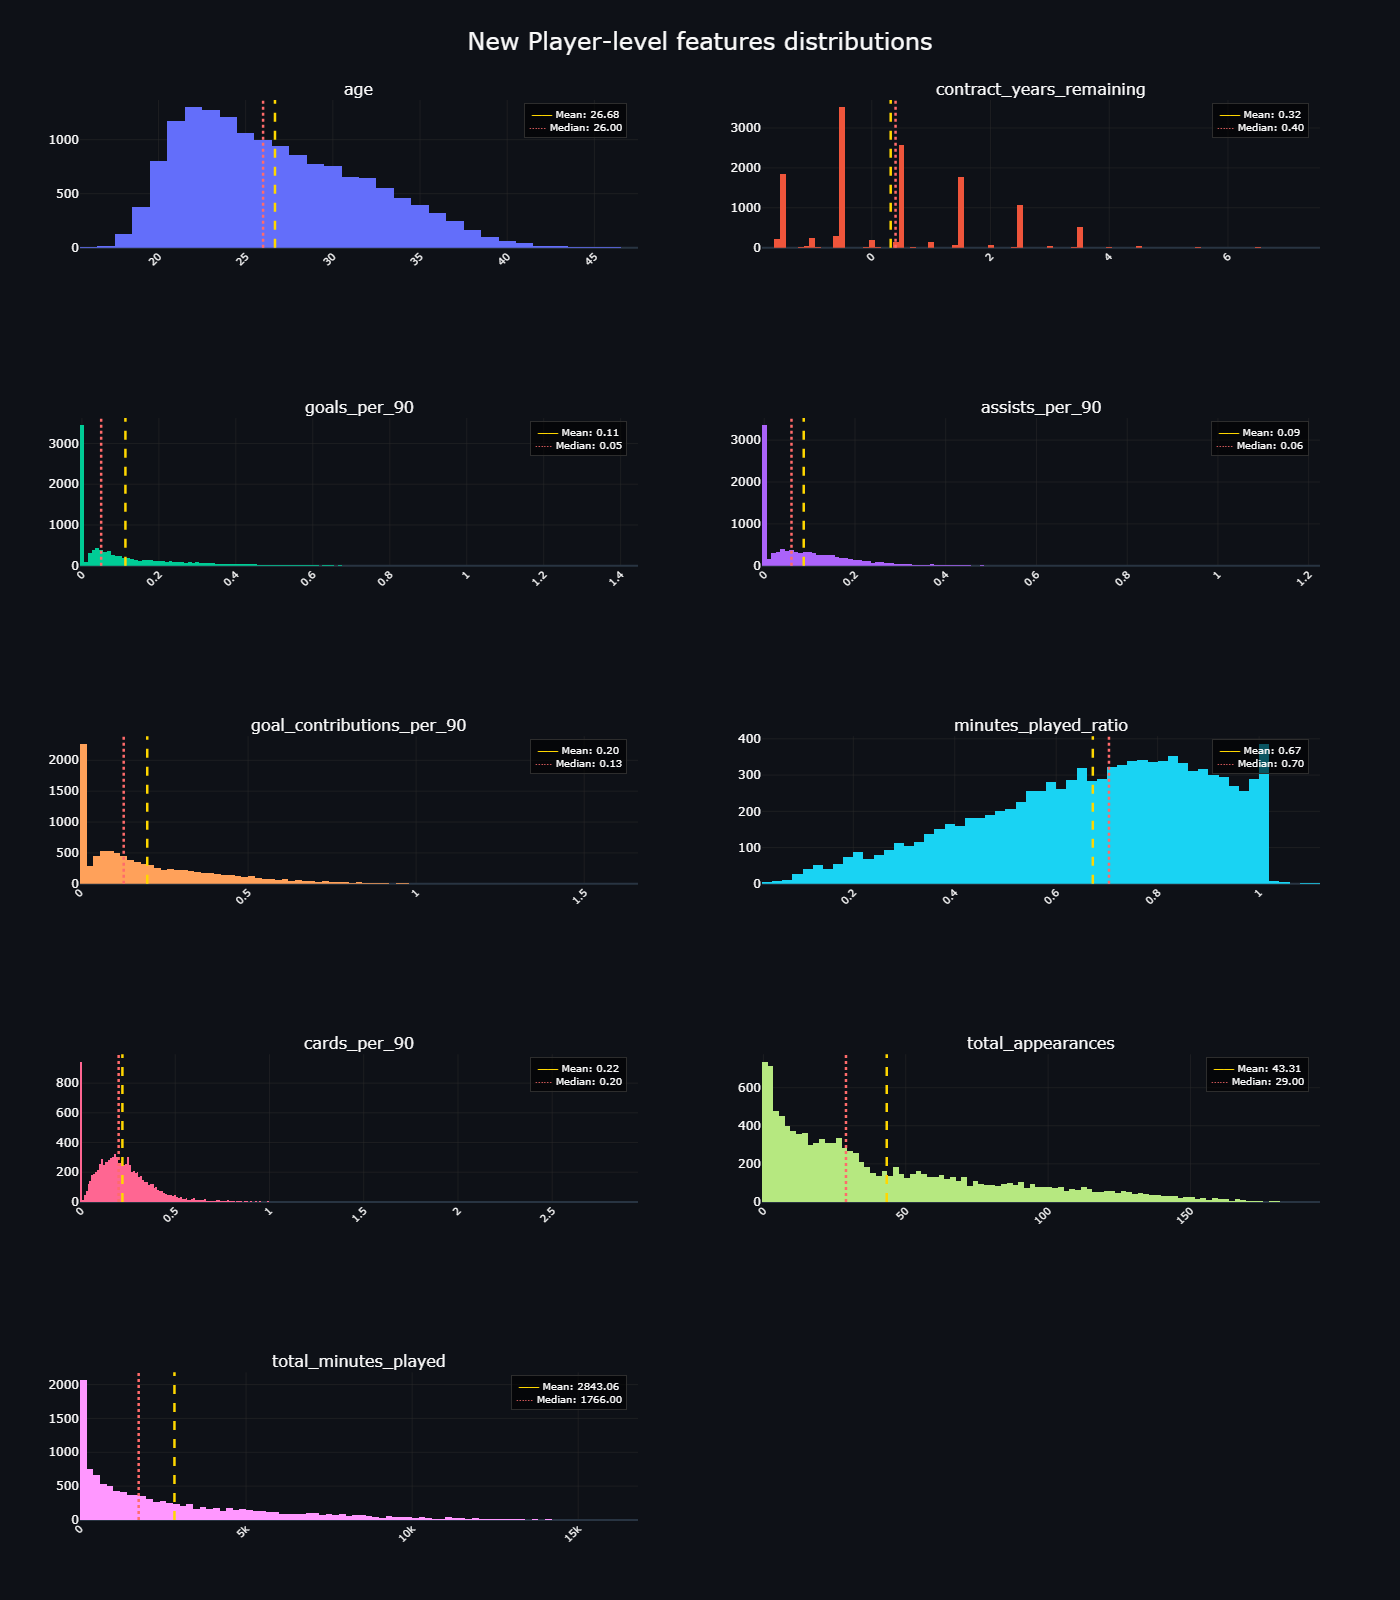

In [8]:
ignore_list = [
'player_id',
'current_club_id',
'player_code',
'country_of_birth',
'city_of_birth',
'country_of_citizenship',
'date_of_birth',
'sub_position',
'position',
'foot',
'height_in_cm',
'contract_expiration_date'
]

players_metrics_dist = distribution_plot(players_df, ignore_cols=ignore_list, title='New Player-level features distributions')
players_metrics_dist

<div class="alert alert-block alert-success">

- **as the distributions show , the thresholds are working and we have intersting patterns and distributions to work with future analytics**

<div class="alert alert-block alert-success">

## Game-level metrics plot and overview:

In [9]:
games_df = run_query('select * from games')
games_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17981 entries, 0 to 17980
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_id          17981 non-null  int64  
 1   competition_id   17981 non-null  str    
 2   season           17981 non-null  int64  
 3   date             17981 non-null  object 
 4   home_club_id     17981 non-null  int64  
 5   away_club_id     17981 non-null  int64  
 6   home_club_goals  17981 non-null  int64  
 7   away_club_goals  17981 non-null  int64  
 8   stadium          17981 non-null  str    
 9   attendance       12987 non-null  float64
 10  total_goals      17981 non-null  int64  
 11  goal_difference  17981 non-null  int64  
 12  is_draw          17981 non-null  bool   
 13  home_win         17981 non-null  bool   
 14  away_win         17981 non-null  bool   
dtypes: bool(3), float64(1), int64(8), object(1), str(2)
memory usage: 2.1+ MB


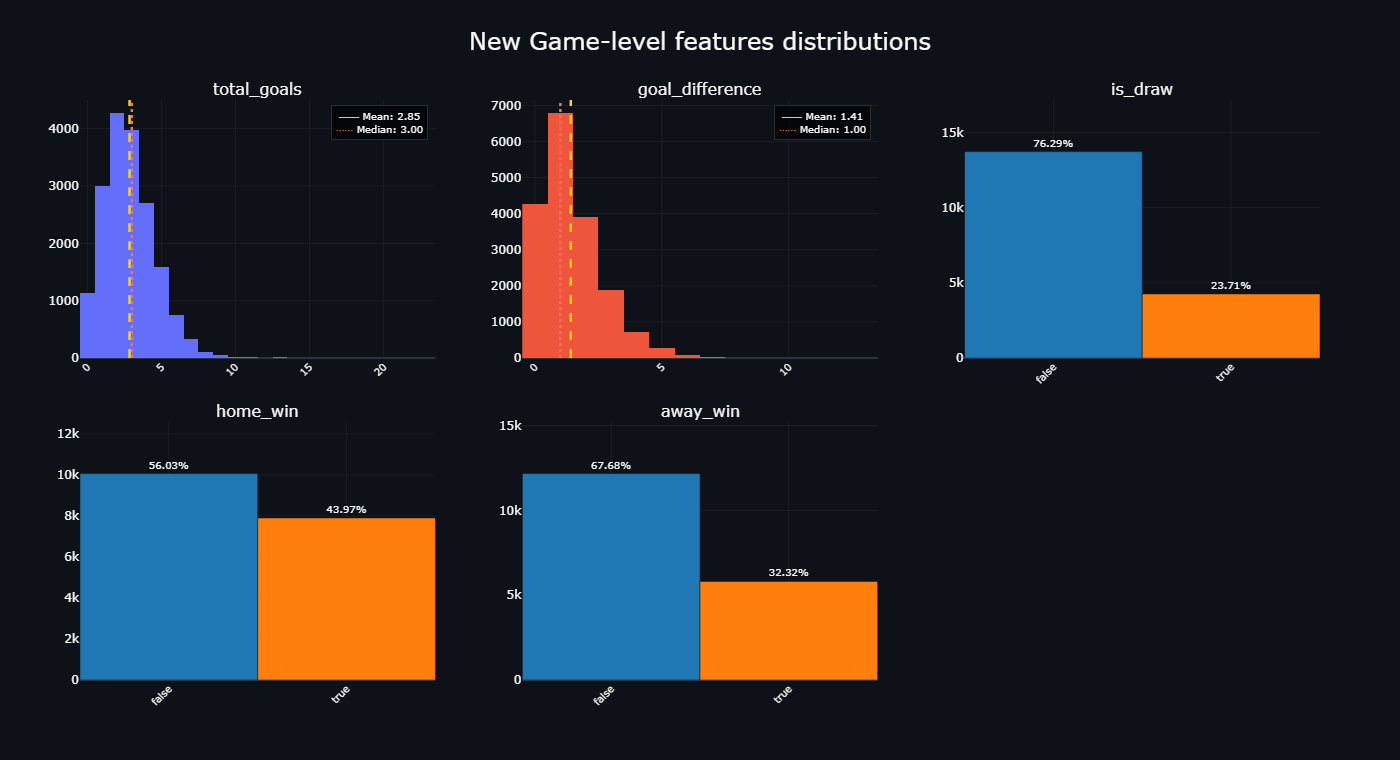

In [10]:
ignore_list = [
'game_id',
'competition_id',
'season',
'date',
'home_club_id',
'away_club_id',
'home_club_goals',
'away_club_goals',
'stadium',
'attendance'
]

games_metrics_dist = distribution_plot(games_df, ignore_cols=ignore_list, n_cols=3, title='New Game-level features distributions')
games_metrics_dist

<div class="alert alert-block alert-success">

- **everything looks fine**
- **A quarter of the games were tied**
- **we can see the win rate in home side is higher then the away side but we still have to check the significance level statistically**

<div class="alert alert-block alert-success">

## Club-level metrics plot and overview:

In [11]:
clubs_df = run_query('select * from clubs')
clubs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   club_id                      426 non-null    int64  
 1   name                         426 non-null    str    
 2   domestic_competition_id      426 non-null    str    
 3   squad_size                   426 non-null    int64  
 4   foreigners_number            426 non-null    int64  
 5   national_team_players        426 non-null    int64  
 6   stadium_name                 426 non-null    str    
 7   stadium_seats                426 non-null    int64  
 8   net_transfer_record          426 non-null    str    
 9   numeric_net_transfer_record  426 non-null    float64
 10  win_rate                     317 non-null    float64
 11  goals_scored_per_game        317 non-null    float64
 12  goals_conceded_per_game      317 non-null    float64
 13  goal_difference_per_game     31

<div class="alert alert-block alert-success">

- **these nulls in new metrics are because some clubs have their data recorded in clubs table but they have no appearance in the games table because total_games metric has some nulls**
- **part of the nulls in ratio metrics are because of the threshold we defined earlier to have more accurate ratio metrics**
- **the nulls in foreigners and national team players ratio are because we have clubs with 0 squad size and for safe division we treated 0 as null so the whole metric for that club becomes null**

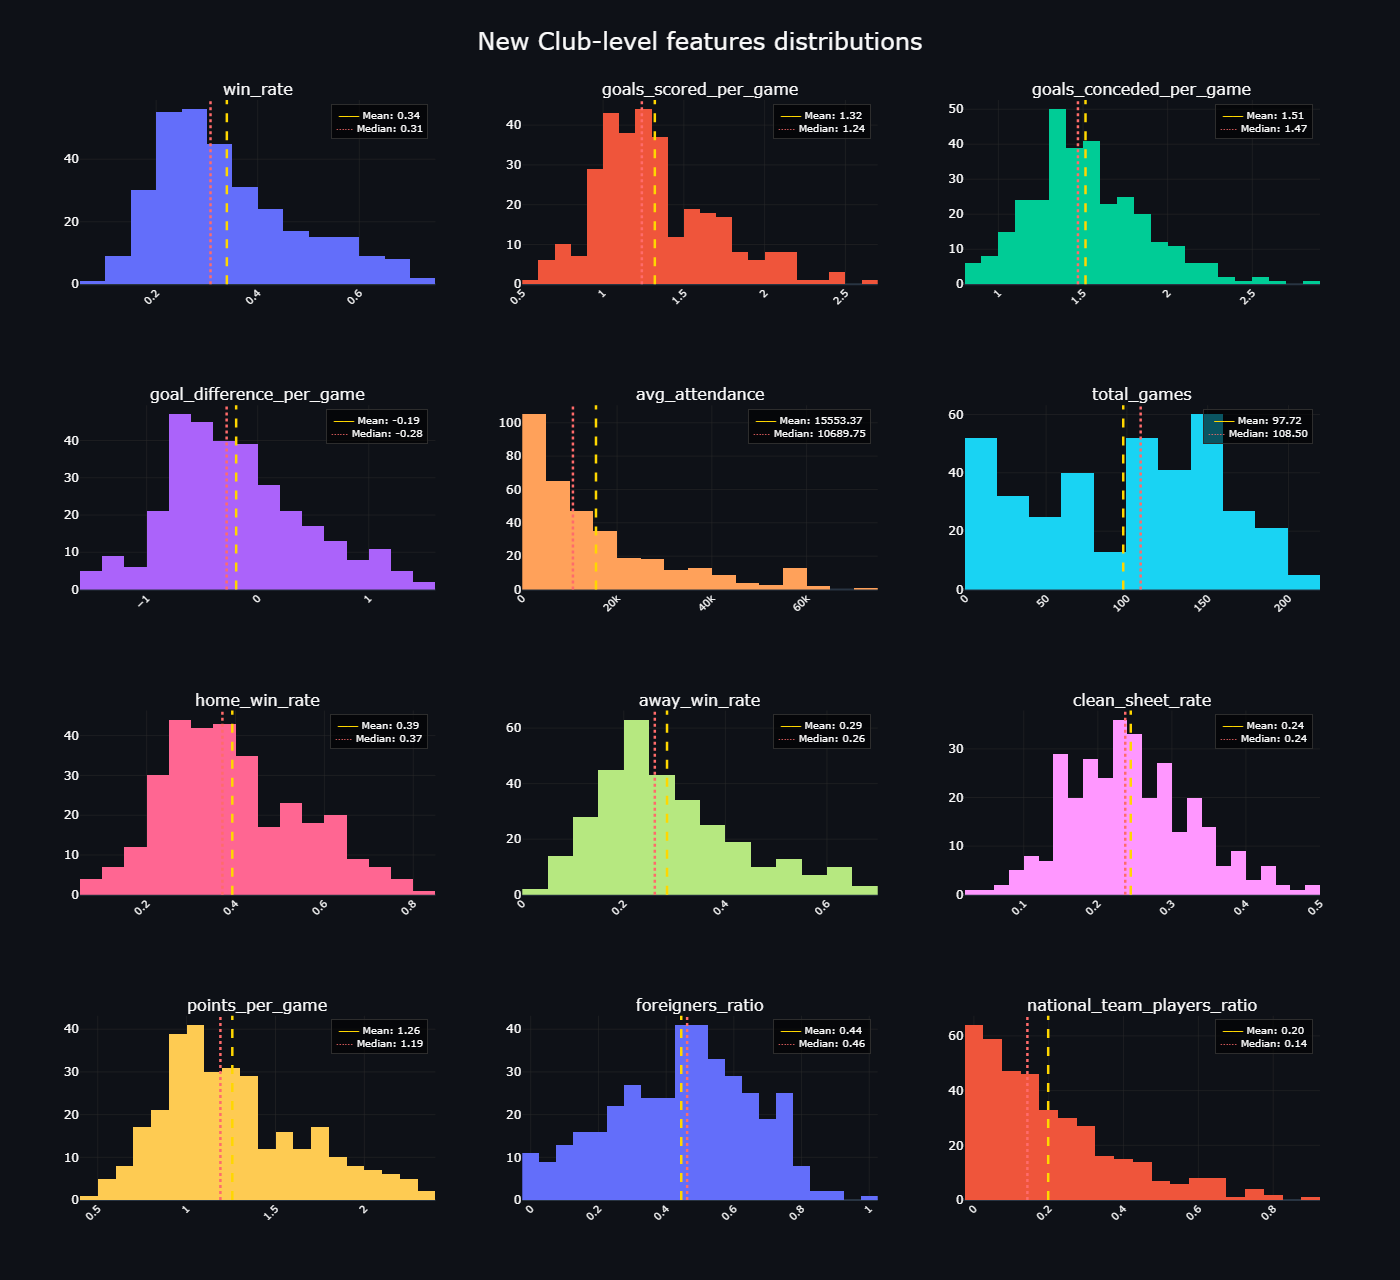

In [12]:
ignore_list = [
'club_id',
'name',
'domestic_competition_id',
'squad_size',
'foreigners_number',
'national_team_players',
'stadium_name',
'stadium_seats',
'net_transfer_record',
'numeric_net_transfer_record'
]

clubs_metrics_dist = distribution_plot(clubs_df, ignore_cols=ignore_list, n_cols=3, title='New Club-level features distributions')
clubs_metrics_dist

<div class="alert alert-block alert-success">

- **we have nice and real distributions showing that treshold is working nicely to avoid biased ratio based on low number of games**
- **avg_attendance and national_team_players gets rarer on higher rates close to 1**
- **most of the distributions have a centered distribution which is possible to normalize them in hypothesis tests**

<div class="alert alert-block alert-success">

# **All the needed features implemented successfully** ✔️
## New features are available on 
- Players table
- Games table
- Clubs table